# Confidence Thresholds

In [55]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path('../data/processed/')
KEYPOINT_DIR = DATA_DIR / 'keypoints'

MOVENET_DIR = KEYPOINT_DIR / 'movenet'
MEDIAPIPE_DIR = KEYPOINT_DIR / 'mediapipe_norm'
OUT_DIR = DATA_DIR / 'confidence_stats'

JOINTS = [
    'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist', 'left_hip', 'right_hip',
    'left_knee', 'right_knee', 'left_ankle', 'right_ankle',
]

In [56]:
def load_files(path):
    files = []
    for file in path.rglob('*.csv'):
        files.append(pd.read_csv(file))
    return files


movenet_files = load_files(MOVENET_DIR)
mediapipe_files = load_files(MEDIAPIPE_DIR)

print(f'movenet: {pd.concat(movenet_files).shape}')
print(f'mediapipe: {pd.concat(mediapipe_files).shape}')

movenet: (15010, 38)
mediapipe: (15010, 62)


In [57]:
THRESHOLDS = np.arange(0.0, 1.1, 0.1)
MAX_ALLOWED_GAP_SIZE = 10

print(f'thresholds: {THRESHOLDS}')
print(f'gap size: {MAX_ALLOWED_GAP_SIZE}')

thresholds: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
gap size: 10


In [58]:
def ratio_below_threshold(df_list, threshold, metric):
    confidence_columns = [f'{joint}_{metric}' for joint in JOINTS]
    df = pd.concat(df_list)[confidence_columns]
    low_confidence = df < threshold
    return np.sum(low_confidence) / df.size

ratio_below_threshold(movenet_files, 0.5, 'confidence')

np.float64(0.08358871863202309)

In [59]:
def find_gaps(df, threshold, metric, min_gap_size=None, max_gap_size=None):
    joint_dict = {}
    confidence_columns = [f'{joint}_{metric}' for joint in JOINTS]
    df = df[confidence_columns]
    low_confidence = df < threshold
    for col_name, col in low_confidence.items():
        col = col.to_numpy()
        padded = np.pad(col, ((1, 1)), constant_values=False)
        diff = np.diff(padded.astype(int))
        gap_starts = np.argwhere(diff == 1)
        gap_ends = np.argwhere(diff == -1)
        gaps = np.hstack((gap_starts, gap_ends))
        if (min_gap_size is not None) and (len(gaps) > 0):
            gaps = gaps[gaps[:, 1] - gaps[:, 0] >= min_gap_size]
        if (max_gap_size is not None) and (len(gaps) > 0):
            gaps = gaps[gaps[:, 1] - gaps[:, 0] <= max_gap_size]
        joint_dict[col_name.removesuffix(f'_{metric}')] = gaps
    return joint_dict


def n_gaps_exceeding(df_list, threshold, metric, max_allowed_gap_size):
    total_gaps = 0
    for df in df_list:
        gap_dict = find_gaps(df, threshold, metric, min_gap_size=max_allowed_gap_size+1)
        n_gaps = 0
        for array in gap_dict.values():
            n_gaps += len(array)
        total_gaps += n_gaps
    return total_gaps
            

n_gaps_exceeding(movenet_files, 0.5, 'confidence', 10)

245

In [60]:
def get_table(df_list, thresholds, metric, max_allowed_gap_size):
    ratios = np.array([ratio_below_threshold(df_list, t, metric) for t in thresholds])
    n_gaps = np.array([n_gaps_exceeding(df_list, t, metric, max_allowed_gap_size) for t in thresholds])
    table = pd.DataFrame.from_dict({
        metric: thresholds,
        '% below': ratios * 100,
        f'gaps > {max_allowed_gap_size}': n_gaps
    })
    return table


def merge_models(df_movenet, df_mediapipe):
    mn = df_movenet.rename(columns={"confidence": "threshold"}).assign(model="movenet")
    mp = df_mediapipe.rename(columns={"visibility": "threshold"}).assign(model="mediapipe")
    out = (pd.concat([mn, mp], keys=[0, 1])
        .swaplevel(0, 1)
        .sort_index(level=0)
        .reset_index(drop=True))
    cols = out.columns.tolist()
    cols.insert(cols.index("threshold") + 1, cols.pop(cols.index("model")))
    return out[cols]


def plot_results(table, model_name, out_dir):
    metric = table.columns[0]

    fig, axes = plt.subplots(ncols=2)
    fig.set_figwidth(16)

    axes[0].plot(table.iloc[:, 0], table.iloc[:, 1])
    axes[0].set(xlabel=f'{metric} threshold', ylabel='% below', title=f'Percentage of keypoints below different {metric} thresholds')
    axes[0].grid(True)

    axes[1].plot(table.iloc[:, 0], table.iloc[:, 2])
    axes[1].set(xlabel=f'{metric} threshold', ylabel='number of gaps', title=f'Number of {table.columns[2]} frames at different {metric} thresholds')
    axes[1].grid(True)

    fig.suptitle(f'{model_name} {metric} thresholds')
    plt.savefig(Path(out_dir) / f'{model_name}_threshold_plots.png')
    plt.show()


def run_analysis(df_list, thresholds, metric, max_allowed_gap_size, model_name, out_dir):
    table = get_table(df_list, thresholds, metric, max_allowed_gap_size, model_name, out_dir)
    plot_results(table, model_name, out_dir)

## Movenet

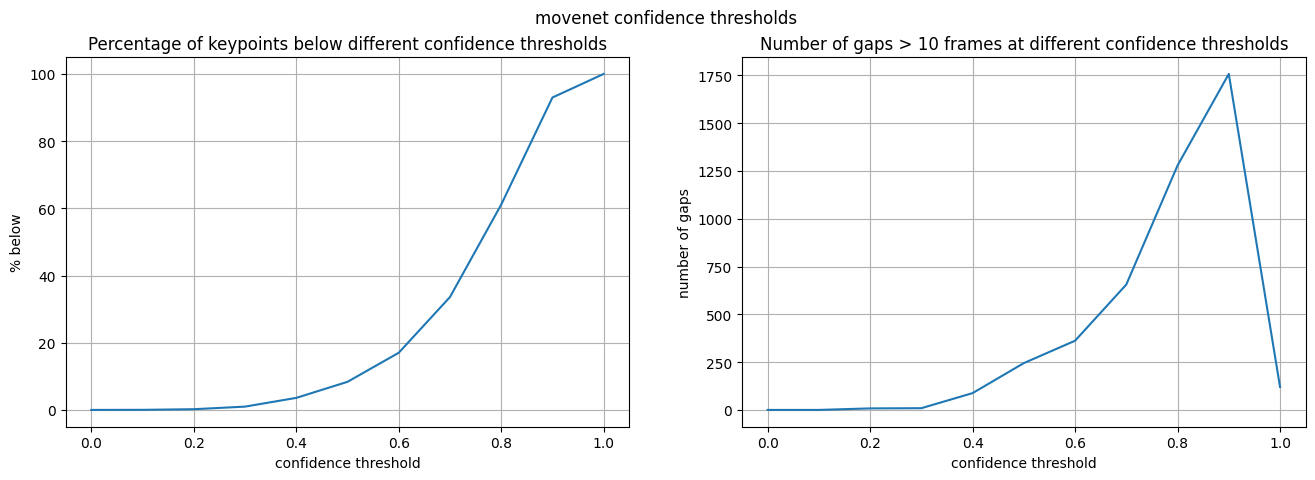

In [61]:
movenet_table = get_table(movenet_files, THRESHOLDS, 'confidence', MAX_ALLOWED_GAP_SIZE)
plot_results(movenet_table, 'movenet', OUT_DIR)

## Mediapipe

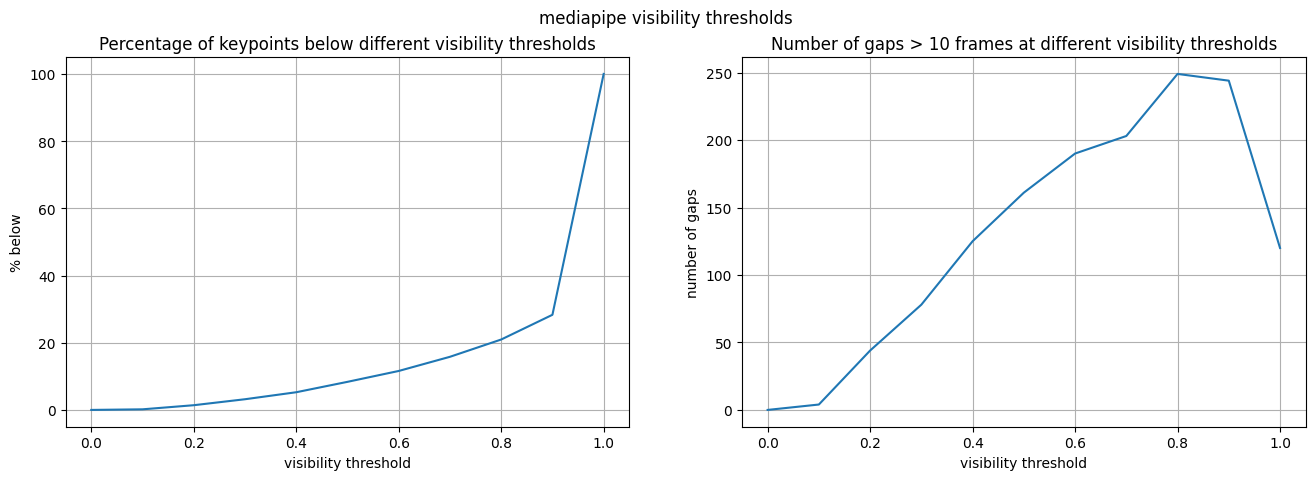

In [62]:
mediapipe_table = get_table(mediapipe_files, THRESHOLDS, 'visibility', MAX_ALLOWED_GAP_SIZE)
plot_results(mediapipe_table, 'mediapipe', OUT_DIR)

In [63]:
merged_table = merge_models(movenet_table, mediapipe_table)
merged_table

,threshold,model,% below,gaps > 10
0,0.0,movenet,0.000000,0
1,0.0,mediapipe,0.000000,0
2,0.1,movenet,0.026649,0
3,0.1,mediapipe,0.178215,4
4,0.2,movenet,0.213191,8
5,0.2,mediapipe,1.401288,44
6,0.3,movenet,0.982123,9
7,0.3,mediapipe,3.180102,78
8,0.4,movenet,3.580946,88
9,0.4,mediapipe,5.263158,125


In [64]:
merged_table.to_csv(Path(OUT_DIR) / 'threshold_table.csv', sep=',', index=False)